In [2]:
import numpy as np
import scipy.sparse.linalg
import matplotlib.pyplot as plt
import typing
import cv2
import torch

from util.solver import assemble_poisson_problem, assemble_biharmonic_problem, scipy_solve
from util.preparation import get_laplacian_map, masked_region_with_source
from util.misc import plt_subplot

np.set_printoptions(linewidth=200) 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

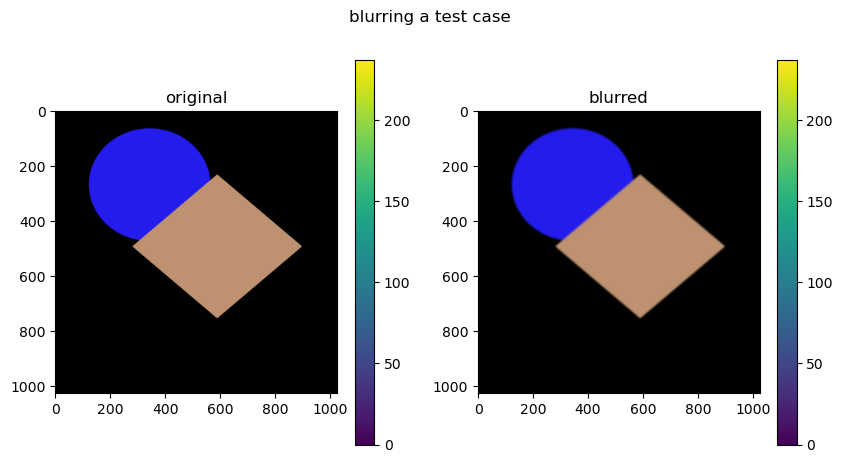

In [ ]:
img = cv2.imread("./var/color_testcase/bmp/overlapping_shapes.bmp", cv2.IMREAD_COLOR)

# Apply Gaussian blur
blurred = cv2.GaussianBlur(img, ksize=(21, 21), sigmaX=3)

cv2.imwrite("overlapping_shapes_blurred.bmp", blurred)

plt_subplot({
    "original": img,
    "blurred": blurred
}, suptitle="blurring a test case")

Testing boundary condition reading for colored images

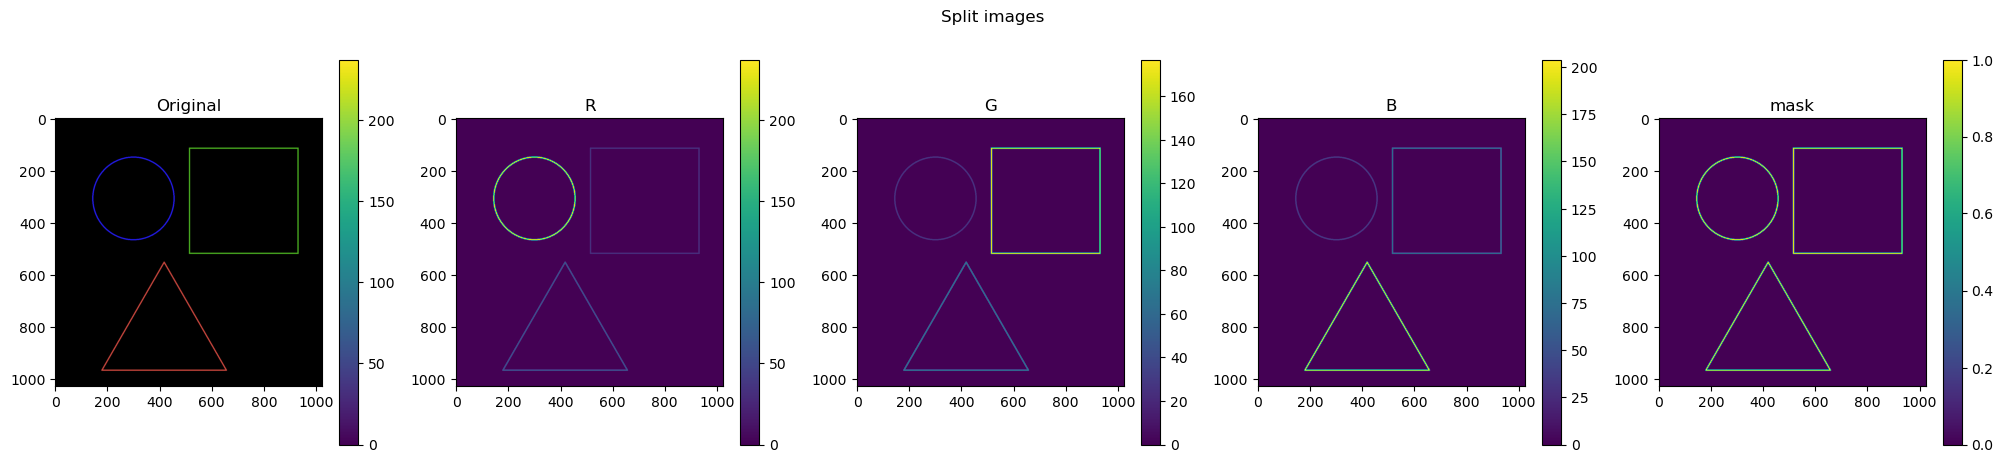

In [ ]:
img = cv2.imread('./var/color_testcase/bmp/three_shapes.bmp', cv2.IMREAD_COLOR)
B, G, R = cv2.split(img) # assuming black means interior pixel, the split image is the exact bc_value
bc_mask = ((R > 0) | (G > 0) | (B > 0)).astype(np.float32)
bc_value_R = R.astype(np.float32)
bc_value_G = G.astype(np.float32)
bc_value_B = B.astype(np.float32)

f = np.zeros_like(bc_mask)
for c in range(3):
    f[c] = img[..., c].astype(np.float32)
    f[c][bc_mask == 1] = 0  # zero out boundary pixels
    
bc_mask = torch.from_numpy(bc_mask_np).unsqueeze(0).unsqueeze(0).to(device)       # (1,1,H,W)
bc_value = torch.from_numpy(bc_value_np).unsqueeze(0).to(device)                  # (1,3,H,W)
f = torch.from_numpy(f_np).unsqueeze(0).to(device)                                # (1,3,H,W)

plt_subplot({
    "Original": img,
    "R": R,
    "G": G,
    "B": B,
    "mask": bc_mask
}, suptitle="Split images",)

In [ ]:
bc_value_zeros: np.ndarray = np.zeros_like(bc_mask, dtype=np.float32)
bc_value_R = R * bc_mask
bc_value_G = G * bc_mask
bc_value_B = B * bc_mask
plt_subplot({
    "Original": img,
    "R": R,
    "G": G,
    "B": B,
    "mask": bc_mask
}, suptitle="bc values")

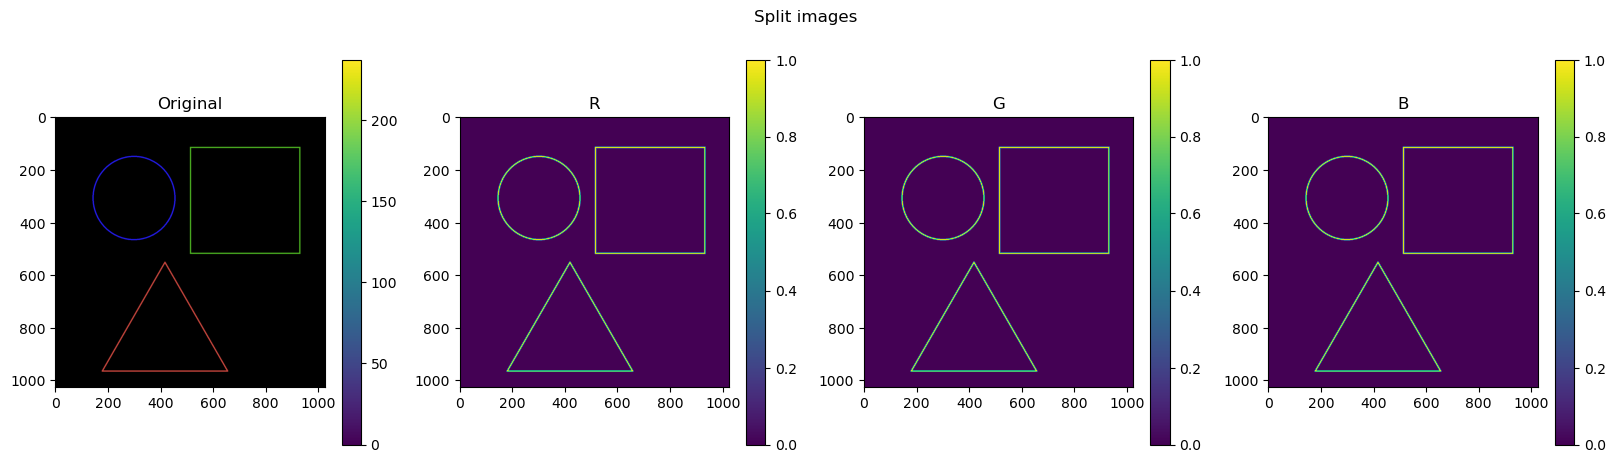

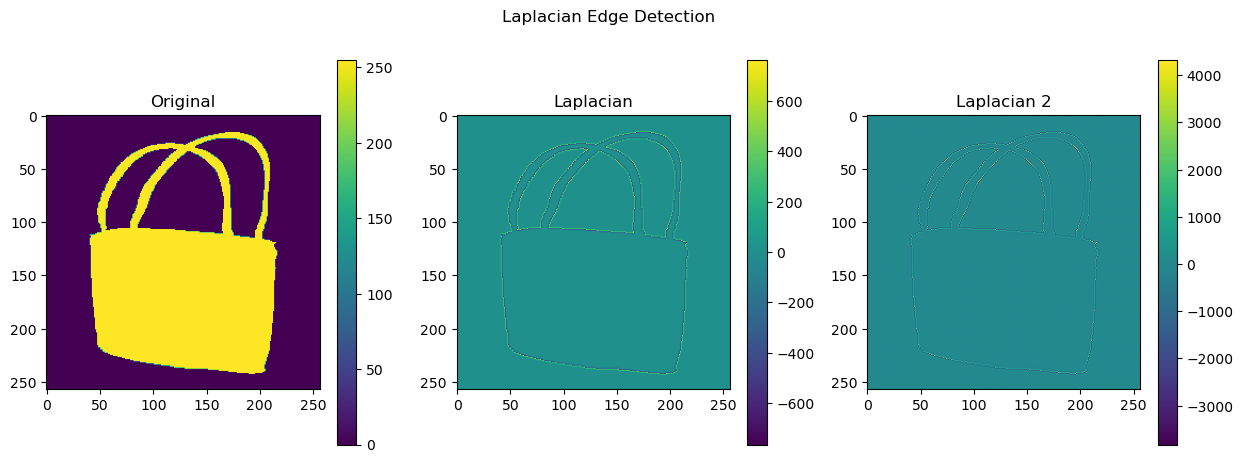

In [2]:
img = cv2.imread("var/testcase/bmp/257/bag.bmp", cv2.IMREAD_GRAYSCALE)  # ensures 2D grayscale
img = img.astype(np.float32)  # convert to float32

lap_map = get_laplacian_map(img)
lap2_map = get_laplacian_map(lap_map)

plt_subplot({
    "Original": img,
    "Laplacian": lap_map,
    "Laplacian 2": lap2_map
}, suptitle="Laplacian Edge Detection", unit_size=5)


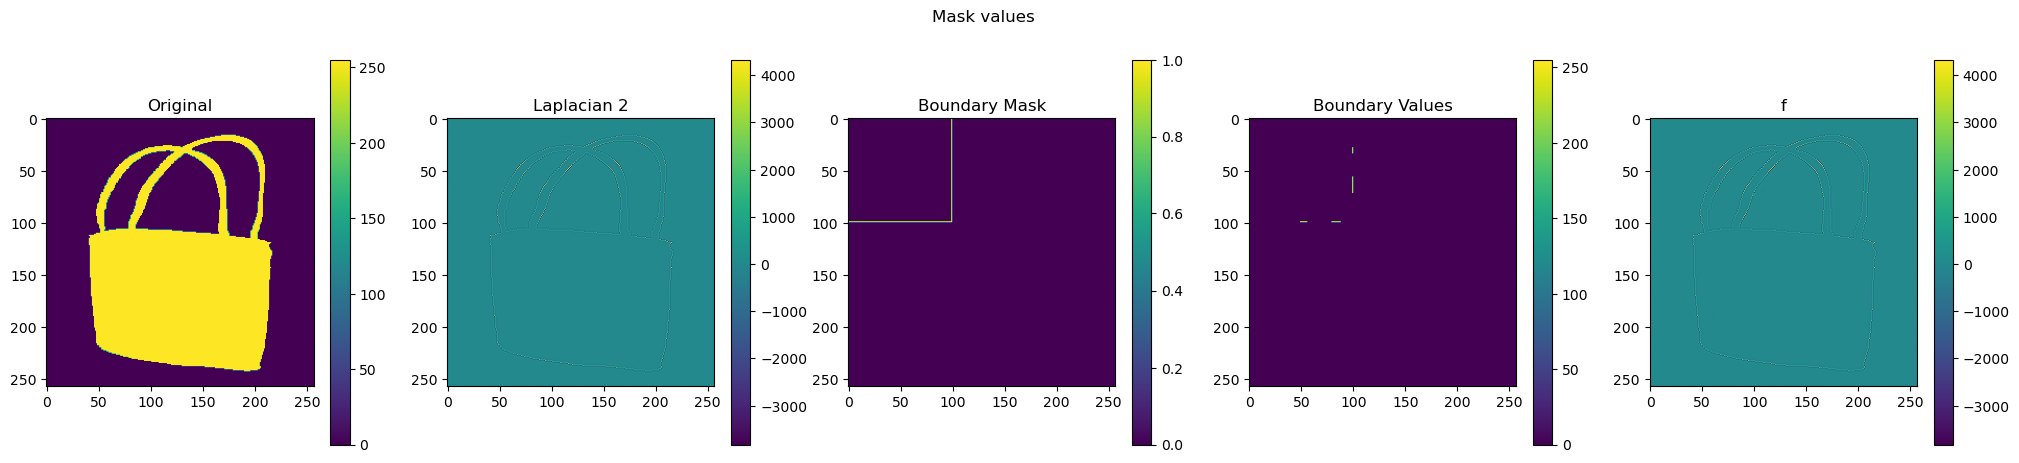

In [3]:
# a version from util/solver.py but with assemble_biharmonic_problem
def scipy_solve_biharmonic(bc_value: np.ndarray,
                bc_mask: np.ndarray,
                f: typing.Optional[np.ndarray]):
    A, rhs = assemble_biharmonic_problem(bc_value, bc_mask, f)
    X = scipy.sparse.linalg.spsolve(A, rhs)
    X.resize(bc_mask.shape)
    return X.astype(np.float32), A, rhs.reshape(f.shape) # returning rhs for debugging

bc_value, bc_mask, f = masked_region_with_source(source=img, derivative=lap2_map, device=device)
# bc_value = np.zeros_like(lap_map)
# bc_mask = np.ones_like(lap_map)
# f = lap_map

# convert it back to numpy tensor just for testing, so that scipy legacy solver can be used
if isinstance(bc_value, torch.Tensor):
    bc_value = bc_value.squeeze().detach().cpu().numpy()
if isinstance(bc_mask, torch.Tensor):
    bc_mask = bc_mask.squeeze().detach().cpu().numpy()
if isinstance(f, torch.Tensor):
    f = f.detach().squeeze().cpu().numpy()

plt_subplot({
    "Original": img,
    "Laplacian 2": lap2_map,
    "Boundary Mask": bc_mask,
    "Boundary Values": bc_value,
    "f" : f
}, suptitle="Mask values", unit_size=5)

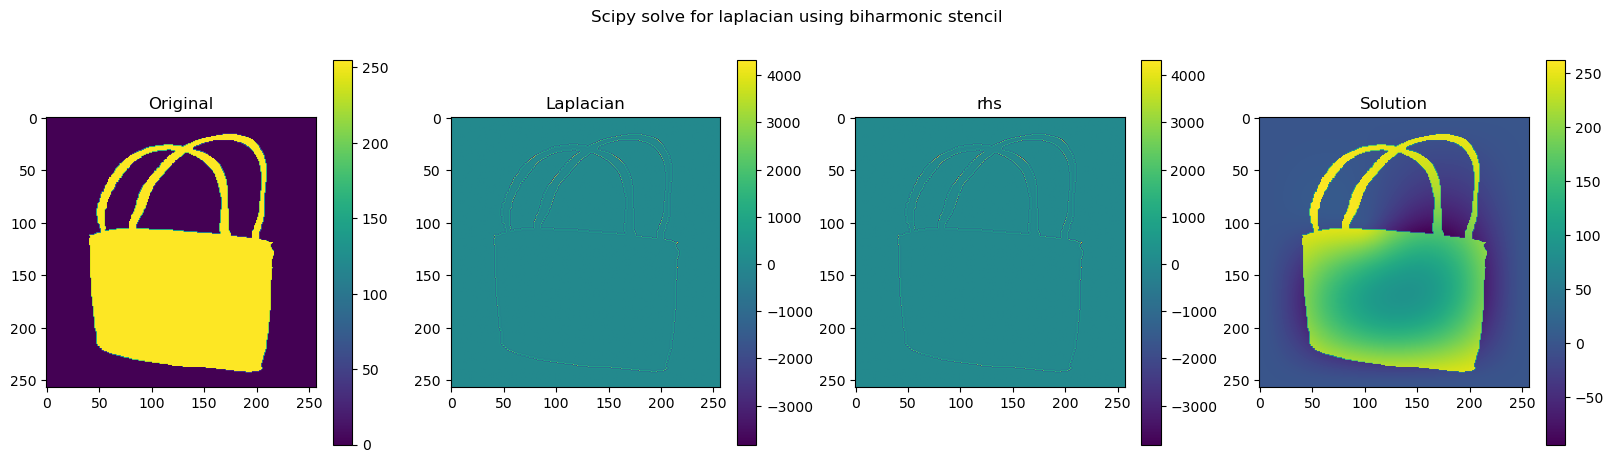

In [4]:
solution, A, rhs = scipy_solve_biharmonic(bc_value.astype(np.float32), bc_mask.astype(np.float32), f.astype(np.float32))
plt_subplot({
    "Original": img,
    "Laplacian": lap2_map,
    "rhs": rhs,
    "Solution": solution
}, suptitle="Scipy solve for laplacian using biharmonic stencil", unit_size=5)

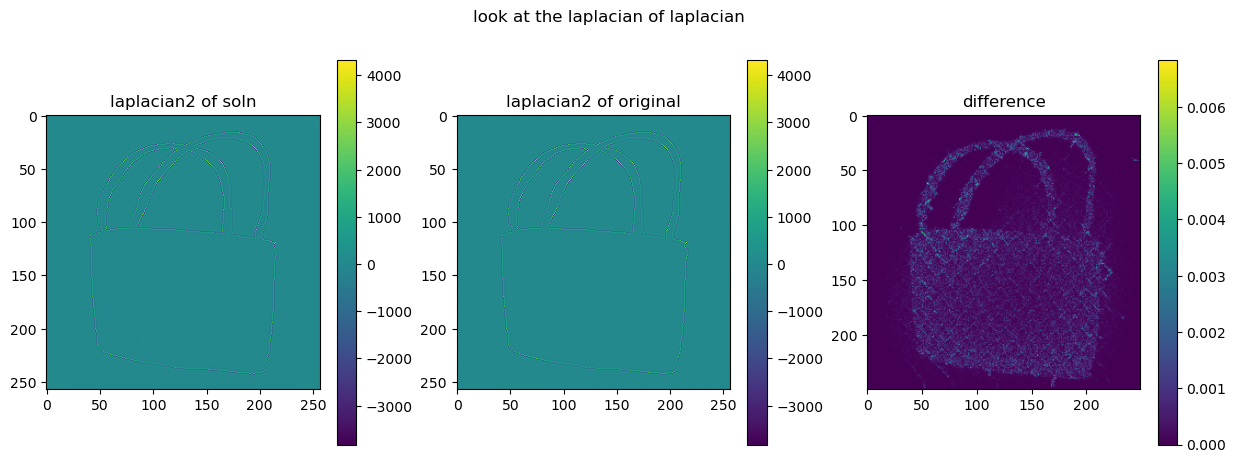

In [5]:
lap2_of_solution = get_laplacian_map(get_laplacian_map(solution))
diff = np.abs(lap2_map - lap2_of_solution)
diff = diff * (1-bc_mask)
diff_sliced = diff[2:252, 2:252]
plt_subplot({
    "laplacian2 of soln":lap2_of_solution,
    "laplacian2 of original":lap2_map,
    "difference":diff_sliced
}, suptitle="look at the laplacian of laplacian", unit_size=5)

1.375028e-06


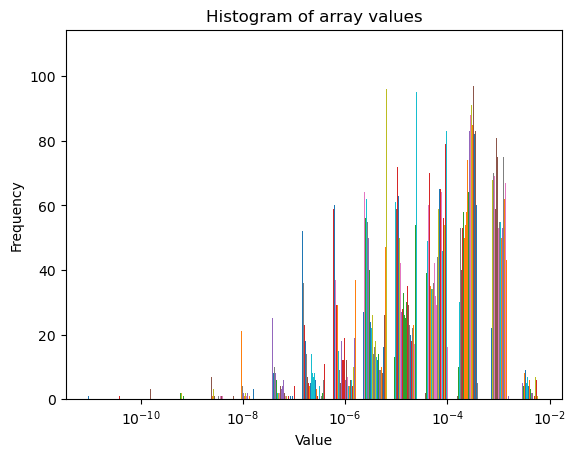

In [6]:
lap2_map_sliced = lap2_map[2:252, 2:252]
relative_error = np.linalg.norm(diff_sliced)/np.linalg.norm(lap2_map_sliced)
print(relative_error)

diff_flat = diff_sliced.flatten()
diff_flat = diff_flat[diff_flat > 0]

bins = np.logspace(np.log10(diff_flat.min()), np.log10(diff_flat.max()), 16)
plt.hist(diff_sliced, bins)  # adjust bins for granularity
plt.xlabel("Value")
plt.xscale("log")
plt.ylabel("Frequency")
plt.title("Histogram of array values")
plt.show()

[0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0.]


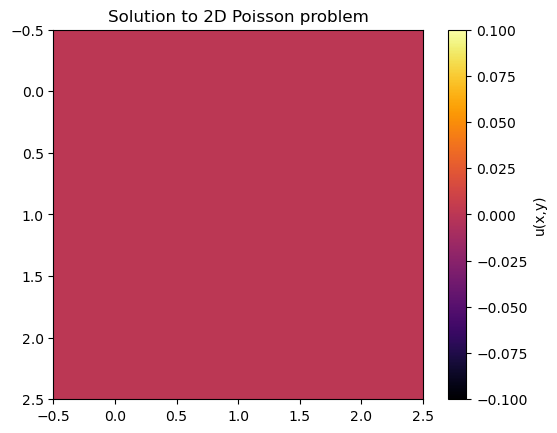

In [8]:
N = 3  # grid size
bc_mask = np.zeros((N, N), dtype=np.uint8)
bc_value = np.zeros((N, N), dtype=np.float32)
f = np.zeros((N, N), dtype=np.float32)

# set boundary condition (u = 1 at top edge, 0 elsewhere)
# bc_mask[0, :] = 1
# bc_value[0, :] = 1.0

# assemble system
A, rhs = assemble_poisson_problem(bc_value, bc_mask, f)

# solve linear system
u = scipy.sparse.linalg.spsolve(A, rhs)

# reshape back to grid
u_grid = u.reshape(N, N)

# visualize
plt.imshow(u_grid, cmap="inferno")
plt.colorbar(label="u(x,y)")
plt.title("Solution to 2D Poisson problem")
plt.show()

In [9]:
np.set_printoptions(linewidth=200) 
print("Right-hand side (rhs):")
print(rhs.reshape(N, N))

print(f"\nSparse matrix A (dense view) {A.shape}:")
dense_A = A.toarray()
for row in dense_A:
    print(row)


Right-hand side (rhs):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Sparse matrix A (dense view) (9, 9):
[-4.  1.  0.  1.  0.  0.  0.  0.  0.]
[ 1. -4.  1.  0.  1.  0.  0.  0.  0.]
[ 0.  1. -4.  0.  0.  1.  0.  0.  0.]
[ 1.  0.  0. -4.  1.  0.  1.  0.  0.]
[ 0.  1.  0.  1. -4.  1.  0.  1.  0.]
[ 0.  0.  1.  0.  1. -4.  0.  0.  1.]
[ 0.  0.  0.  1.  0.  0. -4.  1.  0.]
[ 0.  0.  0.  0.  1.  0.  1. -4.  1.]
[ 0.  0.  0.  0.  0.  1.  0.  1. -4.]


In [10]:
N2 = 5  # grid size
bc_mask = np.zeros((N2, N2), dtype=np.uint8)
bc_value = np.zeros((N2, N2), dtype=np.float32)
f = np.zeros((N2, N2), dtype=np.float32)
A, rhs = assemble_biharmonic_problem(bc_value, bc_mask, f)
print("Right-hand side (rhs):")
print(rhs.reshape(N2, N2))

print(f"\nSparse matrix A (dense view) {A.shape}:")
dense_A = A.toarray()
for row in dense_A:
    print(row)

Right-hand side (rhs):
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Sparse matrix A (dense view) (25, 25):
[20. -8.  1.  0.  0. -8.  2.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
[-8. 20. -8.  1.  0.  2. -8.  2.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
[ 1. -8. 20. -8.  1.  0.  2. -8.  2.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
[ 0.  1. -8. 20. -8.  0.  0.  2. -8.  2.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
[ 0.  0.  1. -8. 20.  0.  0.  0.  2. -8.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
[-8.  2.  0.  0.  0. 20. -8.  1.  0.  0. -8.  2.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
[ 2. -8.  2.  0.  0. -8. 20. -8.  1.  0.  2. -8.  2.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
[ 0.  2. -8.  2.  0.  1. -8. 20. -8.  1.  0.  2. -8.  2.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.]
[ 0.  0.  2. -8.  2.  0.  1. -